# LoRA SFT 파인튜닝 (SKALA Shop 업무 규칙 학습)

## 실습 목표

일반 SQL 문법은 알지만 SKALA Shop의 업무 규칙은 모르는 Baseline 모델을
질문–정답 SQL 데이터로 파인튜닝하여, 학습 전후 규칙 준수율을 비교합니다.

(Baseline vs Fine-Tuned Model)

## SKALA Shop 업무 규칙 : 매출 분석 SQL 작성 기준

1. 유효 주문: `status = 'COMPLETED'`
2. 실매출: `quantity * unit_price * (1 - discount_rate)`
3. 월 기간: 해당 월 시작일 이상, 다음 달 시작일 미만
4. 매출 별칭: `total_revenue`
5. 출력 형식: `SELECT`문만 생성, 세미콜론으로 종료

## 학습 데이터

규칙 기반 프로그램으로 생성한 교육용 합성 데이터입니다. 실습 시작 전 아래 두 파일을 준비하세요.

| 파일 | 역할 |
|---|---|
| `skala_sql_train.jsonl` | LoRA 어댑터 학습용 (question, sql) |
| `skala_sql_test.jsonl` | 규칙 준수 평가용 (question, sql, 채점 메타) |

노트북 실행 중 "1. 데이터 업로드 단계"에서 두 파일을 직접 업로드합니다.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Colab GPU 환경 설정 [Colab 전용]

- 런타임 > 런타임 유형 변경 > 하드웨어 가속기: T4 GPU 선택 후 저장
- 로컬 환경 사용자는 이 섹션 건너뛰기
- 무료 Colab은 세션 시간과 GPU 사용량에 제한이 있음. 연결이 끊기면 런타임을 다시 시작하고 위 셀부터 재실행

In [1]:
!pip install -q \
    transformers==4.56.1 trl==0.23.1 peft==0.17.1 datasets==4.0.0 accelerate==1.10.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.6/564.6 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


- gradio와 huggingface-hub 버전 충돌 경고가 나올 수 있습니다.
- 이 실습은 gradio를 사용하지 않으므로 무시하고 다음 셀을 진행하세요.

In [2]:
import os
import random
import statistics
from collections import defaultdict

import pandas as pd
import torch
from datasets import load_dataset
from peft import LoraConfig
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

assert torch.cuda.is_available(), "GPU 런타임 필요"


## 1. 데이터 업로드

In [3]:
REQUIRED_FILES = ["skala_sql_train.jsonl", "skala_sql_test.jsonl"]

def ensure_data_files():
    missing = [f for f in REQUIRED_FILES if not os.path.exists(f)]
    if not missing:
        print("데이터 파일 확인 완료:", REQUIRED_FILES)
        return

    try:
        from google.colab import files
        print("다음 파일을 업로드하세요:", missing)
        files.upload()
        still_missing = [f for f in REQUIRED_FILES if not os.path.exists(f)]
        if still_missing:
            raise FileNotFoundError(f"업로드되지 않은 파일이 있습니다: {still_missing}")
        print("업로드 완료:", REQUIRED_FILES)
    except ImportError:
        raise FileNotFoundError(
        )

ensure_data_files()


데이터 파일 확인 완료: ['skala_sql_train.jsonl', 'skala_sql_test.jsonl']


In [4]:
# train(question,sql)과 test(+채점 메타)는 컬럼이 달라 따로 로드
train_raw = load_dataset("json", data_files="skala_sql_train.jsonl", split="train")
test_raw  = load_dataset("json", data_files="skala_sql_test.jsonl",  split="train")
print(train_raw, test_raw)


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['question', 'sql'],
    num_rows: 400
}) Dataset({
    features: ['question', 'sql', 'kind', 'dim', 'n', 'start', 'end', 'requirements'],
    num_rows: 20
})


In [5]:
# train은 질문↔정답 쌍, test는 채점 메타가 더 있다
print("[train]", train_raw[0]["question"]); print(train_raw[0]["sql"])
print("\n[test 메타]", test_raw[0]["kind"], test_raw[0]["requirements"])


[train] 2026년 11월 월별 실매출을 알려주세요.
SELECT
    SUM(quantity * unit_price * (1 - discount_rate)) AS total_revenue
FROM skala_orders
WHERE status = 'COMPLETED'
  AND order_date >= '2026-11-01'
  AND order_date < '2026-12-01';

[test 메타] total ['select_only', 'table', 'period', 'formula', 'completed', 'alias', 'semicolon']


## 2. SFT 형식으로 변환

`prompt`엔 스키마+질문만(규칙 없음), `completion`엔 규칙이 반영된 정답 SQL.

In [6]:
SCHEMA = ("CREATE TABLE skala_orders (order_id INT, order_date DATE, region TEXT, "
          "category TEXT, quantity INT, unit_price INT, discount_rate FLOAT, status TEXT);")
SYSTEM = "You write a single SQL SELECT query for the skala_orders table."

def to_sft_record(row):
    prompt_text = f"Database schema:\n{SCHEMA}\n\nQuestion:\n{row['question']}"
    return {
        "prompt":     [{"role": "system", "content": SYSTEM},
                       {"role": "user", "content": prompt_text}],
        "completion": [{"role": "assistant", "content": row["sql"]}],
    }

train_dataset = train_raw.map(to_sft_record)
eval_dataset  = test_raw.map(to_sft_record)


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/20 [00:00<?, ? examples/s]

## 3. Baseline 모델

In [7]:
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float16).to("cuda")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# greedy 디코딩과 충돌하는 샘플링 기본값 해제
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

## 4. 학습전 Baseline 응답 저장

평가는 test 20건 **전체**로 진행합니다. Baseline 응답은 학습 전에 저장해야
학습 후 모델과 동일 조건으로 비교할 수 있습니다.

In [8]:
@torch.no_grad()
def generate_sql(m, question, max_new_tokens=160):
    prompt_text = f"Database schema:\n{SCHEMA}\n\nQuestion:\n{question}"
    messages = [{"role": "system", "content": SYSTEM},
                {"role": "user", "content": prompt_text}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(m.device)
    out = m.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False,
                      pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

# 평가는 test 20건 전체를 고정 세트로 사용. Baseline 응답은 학습 전에 저장(공정 비교)
eval_examples  = [test_raw[i] for i in range(len(test_raw))]
eval_questions = [r["question"] for r in eval_examples]
reference_sql  = [r["sql"] for r in eval_examples]
baseline_answers = [generate_sql(model, q) for q in eval_questions]
print(f"Baseline 응답 {len(baseline_answers)}건 저장 완료")


Baseline 응답 20건 저장 완료


## 5. LoRA로 SFT — 실험 함수화

- 이후 단계에서 Epoch / 학습 데이터 크기 / LoRA Rank를 바꿔가며 여러 번 실험합니다.  
- 같은 런타임에서 설정만 바꿔 학습 셀을 다시 실행하면, 이미 학습된 모델이나
Adapter 상태가 남아 공정한 비교가 되지 않을 수 있습니다.

- 각 실험은 반드시 동일한 원본 Instruct 모델에서 새로 시작해야 합니다.
- 이를 위해 학습 전체 과정을 `run_experiment()` 함수 하나로 묶고,
함수 내부에서 모델을 매번 새로 불러온 뒤 실험이 끝나면 GPU 메모리를 정리합니다.

### 규칙 준수 채점 함수

- 평가는 고정된 test 20건 전체로 진행합니다.
- 문항별로 요구하는 규칙(`requirements`)만 채점합니다.
- 모델이 여러 문장을 출력할 경우를 대비해 첫 번째 세미콜론까지만 채점 대상으로 자릅니다.
- 전체 평균 준수율뿐 아니라, 규칙 항목별 준수율도 함께 집계합니다.  
  (어떤 규칙을 학습 전에는 못 지키다가 학습 후 지키게 됐는지 보기 위함)

In [9]:
def _first_statement(sql):
    """모델이 여러 문장을 출력해도 첫 SELECT문만 채점하도록 자른다."""
    idx = sql.find(";")
    return sql[: idx + 1] if idx != -1 else sql

def check_rules(sql, row):
    sql = _first_statement(sql)
    up = sql.upper(); nz = "".join(up.split())   # 공백·줄바꿈 제거
    res = {
        "select_only": up.lstrip().startswith("SELECT")
                       and all(x not in up for x in ["INSERT", "UPDATE", "DELETE", "DROP"]),
        "table":     "FROM SKALA_ORDERS" in up,
        "formula":   "QUANTITY*UNIT_PRICE*(1-DISCOUNT_RATE)" in nz,
        "completed": "STATUS='COMPLETED'" in nz,
        "alias":     "ASTOTAL_REVENUE" in nz,
        "semicolon": sql.strip().endswith(";"),
        "period":    str(row["start"])[:10] in sql and str(row["end"])[:10] in sql,
    }
    if "groupby" in row["requirements"]:   res["groupby"]   = f"GROUPBY{row['dim']}".upper() in nz
    if "orderdesc" in row["requirements"]: res["orderdesc"] = "ORDERBYTOTAL_REVENUEDESC" in nz
    if "limit" in row["requirements"]:     res["limit"]     = f"LIMIT{row['n']}" in nz
    return {k: res[k] for k in row["requirements"]}   # 문항이 요구한 규칙만 채점

def compliance(sql, row):
    r = check_rules(sql, row)
    return sum(r.values()) / len(r)

def compliance_summary(answers, examples):
    """test 전체에 대한 평균 규칙 준수율."""
    rates = [compliance(sql, row) for sql, row in zip(answers, examples)]
    return statistics.mean(rates)

def rule_breakdown(answers, examples):
    """규칙 항목별 준수율 (해당 규칙이 요구된 문항 기준)."""
    hits = defaultdict(list)
    for sql, row in zip(answers, examples):
        for rule, ok in check_rules(sql, row).items():
            hits[rule].append(ok)
    return {rule: statistics.mean(v) for rule, v in sorted(hits.items())}


### 학습 데이터 서브샘플링 (규칙 유형 비율 유지)

학습 데이터 크기를 줄여서 실험할 때, 단순히 앞부분만 자르면 `GROUP BY`나
`LIMIT`가 들어간 문항이 거의 사라져 "데이터가 적어서 성능이 낮다"가 아니라
"애초에 그 규칙을 배울 기회가 없어서" 성능이 낮아지는 왜곡이 생길 수 있습니다.
SQL에 포함된 절(`GROUP BY`, `LIMIT`)을 기준으로 유형을 추정하고, 그 비율을
유지하며 서브샘플링합니다.

In [10]:
def infer_kind(sql):
    s = sql.upper()
    if "LIMIT" in s:
        return "limit"
    if "GROUP BY" in s:
        return "group"
    return "total"

def sample_train_stratified(dataset, n, seed=42):
    """SQL 유형(total/group/limit) 비율을 유지하며 n건을 샘플링한다."""
    if n >= len(dataset):
        return dataset

    by_kind = defaultdict(list)
    for i, row in enumerate(dataset):
        by_kind[infer_kind(row["sql"])].append(i)

    rng = random.Random(seed)
    picked = []
    for kind, idxs in sorted(by_kind.items()):
        share = round(n * len(idxs) / len(dataset))
        picked += rng.sample(idxs, min(share, len(idxs)))

    remaining = [i for i in range(len(dataset)) if i not in picked]
    rng.shuffle(remaining)
    while len(picked) < n and remaining:
        picked.append(remaining.pop())

    return dataset.select(sorted(picked[:n]))


### 실험 실행 함수

- `run_experiment()`는 매번 원본 Instruct 모델을 새로 불러와 LoRA SFT를 수행하고,
학습 결과와 규칙 준수율을 반환합니다.
- `lora_alpha`는 관례대로 `lora_r`의 2배로
자동 설정됩니다. 함수가 끝나면 GPU 메모리를 정리하므로, 같은 런타임에서
여러 번 이어서 실행해도 이전 실험의 영향을 받지 않습니다.

In [53]:
import time # Add import for time module

def run_experiment(train_size=400, epochs=3, lora_r=8, seed=42, verbose=True):
    start_time = time.time() # Start time measurement

    # 1) 원본 Instruct 모델을 새로 로드 (이전 실험 상태와 분리)
    m = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float16).to("cuda")

    # 2) 학습 데이터 준비 (SQL 유형 비율을 유지한 서브샘플링)
    sub_train = sample_train_stratified(train_dataset, train_size, seed=seed)

    # 3) LoRA 설정 — lora_alpha = 2 * lora_r 자동 적용
    lora_cfg = LoraConfig(
        r=lora_r,
        lora_alpha=2 * lora_r,
        lora_dropout=0.05,
        target_modules=["q_proj", "v_proj"], bias="none",
        task_type="CAUSAL_LM",
    )

    training_args = SFTConfig(
        output_dir=f"outputs/exp_r{lora_r}_ep{epochs}_n{train_size}",
        num_train_epochs=epochs,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        learning_rate=2e-4,
        max_length=512,
        completion_only_loss=True,   # 정답 SQL 부분만 학습
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=10,
        fp16=True,                   # T4는 bf16 미지원
        report_to="none",
        seed=seed,
    )

    trainer = SFTTrainer(
        model=m, args=training_args,
        train_dataset=sub_train, eval_dataset=eval_dataset,
        peft_config=lora_cfg, processing_class=tokenizer,
    )
    if verbose:
        trainer.model.print_trainable_parameters()

    train_result = trainer.train()
    eval_result = trainer.evaluate()

    # 4) 고정된 test 20건 전체로 생성 및 규칙 준수율 계산
    answers = [generate_sql(trainer.model, q) for q in eval_questions]
    overall = compliance_summary(answers, eval_examples)
    breakdown = rule_breakdown(answers, eval_examples)

    end_time = time.time() # End time measurement
    execution_time = round(end_time - start_time, 2)

    result = {
        "config": {"train_size": train_size, "epochs": epochs, "lora_r": lora_r},
        "train_loss": round(train_result.training_loss, 4),
        "eval_loss": round(eval_result["eval_loss"], 4),
        "compliance_rate": overall,
        "rule_breakdown": breakdown,
        "answers": answers,
        "execution_time_sec": execution_time, # Add execution time to results
    }

    # 5) GPU 메모리 정리 (다음 실험을 위해 필수)
    del trainer, m
    torch.cuda.empty_cache()

    return result

## 6. 기본 실험 실행 (Epoch 1 · 학습 데이터 400건 · LoRA Rank 8)

가이드에서 제시하는 기본 설정으로 한 번 학습
 (이 결과가 이후 비교와
심화 실험의 기준점이 됩니다.)

In [54]:
default_result = run_experiment(train_size=400, epochs=1, lora_r=8, seed=42)
finetuned_answers = default_result["answers"]

print("설정:", default_result["config"])
print("Final train loss:", default_result["train_loss"])
print("Eval loss:", default_result["eval_loss"])
print(f"규칙 준수율 (Fine-Tuned): {default_result['compliance_rate']:.1%}")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.010000,0.012162,1.002009,67244.000000,0.997533


설정: {'train_size': 400, 'epochs': 1, 'lora_r': 8}
Final train loss: 0.1376
Eval loss: 0.0122
규칙 준수율 (Fine-Tuned): 92.7%


## 7. Baseline vs Fine-Tuned 비교

In [55]:
baseline_rate = compliance_summary(baseline_answers, eval_examples)
finetuned_rate = default_result["compliance_rate"]
print(f"규칙 준수율 — Baseline: {baseline_rate:.1%}  |  Fine-Tuned: {finetuned_rate:.1%}")


규칙 준수율 — Baseline: 32.2%  |  Fine-Tuned: 92.7%


### 규칙 항목별 준수율 비교

In [56]:
baseline_breakdown = rule_breakdown(baseline_answers, eval_examples)
finetuned_breakdown = default_result["rule_breakdown"]

rules = sorted(set(baseline_breakdown) | set(finetuned_breakdown))
breakdown_df = pd.DataFrame({
    "규칙": rules,
    "Baseline": [f"{baseline_breakdown.get(r, float('nan')):.0%}" for r in rules],
    "Fine-Tuned": [f"{finetuned_breakdown.get(r, float('nan')):.0%}" for r in rules],
})
breakdown_df


,규칙,Baseline,Fine-Tuned
0,alias,0%,100%
1,completed,10%,100%
2,formula,0%,100%
3,groupby,0%,75%
4,limit,100%,100%
5,orderdesc,0%,100%
6,period,0%,55%
7,select_only,100%,100%
8,semicolon,40%,100%
9,table,100%,100%


### 개별 질문 비교 (5건)

In [57]:
for i in range(5):
    row = eval_examples[i]
    print("=" * 80)
    print("[질문]", eval_questions[i])
    print("\n[정답 SQL]\n", reference_sql[i])
    print("\n[Baseline]\n", baseline_answers[i], "\n  준수:", check_rules(baseline_answers[i], row))
    print("\n[Fine-Tuned]\n", finetuned_answers[i], "\n  준수:", check_rules(finetuned_answers[i], row))


[질문] 7월의 전체 실매출 총액이 궁금합니다.

[정답 SQL]
 SELECT
    SUM(quantity * unit_price * (1 - discount_rate)) AS total_revenue
FROM skala_orders
WHERE status = 'COMPLETED'
  AND order_date >= '2026-07-01'
  AND order_date < '2026-08-01';

[Baseline]
 SELECT SUM(quantity * unit_price) AS total_sales FROM skala_orders WHERE strftime('%Y-%m', order_date) = '07-01' 
  준수: {'select_only': True, 'table': True, 'period': False, 'formula': False, 'completed': False, 'alias': False, 'semicolon': False}

[Fine-Tuned]
 SELECT
    SUM(quantity * unit_price * (1 - discount_rate)) AS total_revenue
FROM skala_orders
WHERE status = 'COMPLETED'
  AND order_date >= '2026-07-01'
  AND order_date < '2026-08-01'; 
  준수: {'select_only': True, 'table': True, 'period': True, 'formula': True, 'completed': True, 'alias': True, 'semicolon': True}
[질문] 7월에 지역 기준으로 실매출이 큰 순서대로 뽑아주세요.

[정답 SQL]
 SELECT
    region,
    SUM(quantity * unit_price * (1 - discount_rate)) AS total_revenue
FROM skala_orders
WHERE status = 'COMPLETED'

## 8. 심화 실험 — A / B / C 중 선택

`run_experiment(train_size, epochs, lora_r, seed)`의 인자만 바꿔 다시 호출하면
새로운 실험을 돌릴 수 있습니다.

| 실험 | 바꾸는 값 | 후보 |
|---|---|---|
| A. Epoch 변경 | `epochs` | 1, 3, 10 |
| B. 학습 데이터 크기 | `train_size` | 50, 100, 400 (교육 효과가 가장 직관적) |
| C. LoRA Rank | `lora_r` | 2, 8, 32 (`lora_alpha`는 자동으로 `2 * lora_r`) |

**유의**:
- 위에서 만든 `run_experiment()`는 호출할 때마다 원본 모델을 새로
불러오므로, 아래 셀을 값만 바꿔 여러 번 실행해도 이전 실험의 영향을 받지
않습니다.  
- 다만 GPU 메모리 확보를 위해 한 번에 하나씩 순차 실행하는 것을
권장합니다.

In [78]:
# 아래 값만 바꿔서 실행하세요. (예시는 기본 설정과 동일한 Epoch 3 / 400건 / Rank 8)
# 실험 A: epochs 를 1, 3, 10 으로 바꿔보기
# 실험 B: train_size 를 50, 100, 400 으로 바꿔보기
# 실험 C: lora_r 을 2, 8, 32 로 바꿔보기 (lora_alpha는 자동 적용)

exp_result = run_experiment(train_size=400, epochs=1, lora_r=8, seed=42)

print("설정:", exp_result["config"])
print(f"Train loss: {exp_result['train_loss']}  |  Eval loss: {exp_result['eval_loss']}")
print(f"규칙 준수율: {exp_result['compliance_rate']:.1%}")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.010000,0.012162,1.002009,67244.000000,0.997533


설정: {'train_size': 400, 'epochs': 1, 'lora_r': 8}
Train loss: 0.1376  |  Eval loss: 0.0122
규칙 준수율: 92.7%


In [80]:
# 아래 값만 바꿔서 실행하세요. (예시는 기본 설정과 동일한 Epoch 3 / 400건 / Rank 8)
# 실험 A: epochs 를 1, 3, 10 으로 바꿔보기
# 실험 B: train_size 를 50, 100, 400 으로 바꿔보기
# 실험 C: lora_r 을 2, 8, 32 로 바꿔보기 (lora_alpha는 자동 적용)

exp_result = run_experiment(train_size=400, epochs=3, lora_r=8, seed=42)

print("설정:", exp_result["config"])
print(f"Train loss: {exp_result['train_loss']}  |  Eval loss: {exp_result['eval_loss']}")
print(f"규칙 준수율: {exp_result['compliance_rate']:.1%}")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.001900,0.007612,0.890184,67244.000000,0.997533
2,0.000700,0.004710,0.870228,134488.000000,0.997533
3,0.000600,0.004721,0.867686,201732.000000,0.997533


설정: {'train_size': 400, 'epochs': 3, 'lora_r': 8}
Train loss: 0.0423  |  Eval loss: 0.0047
규칙 준수율: 97.8%


In [60]:
# 아래 값만 바꿔서 실행하세요. (예시는 기본 설정과 동일한 Epoch 3 / 400건 / Rank 8)
# 실험 A: epochs 를 1, 3, 10 으로 바꿔보기
# 실험 B: train_size 를 50, 100, 400 으로 바꿔보기
# 실험 C: lora_r 을 2, 8, 32 로 바꿔보기 (lora_alpha는 자동 적용)

exp_result = run_experiment(train_size=400, epochs=10, lora_r=8, seed=42)

print("설정:", exp_result["config"])
print(f"Train loss: {exp_result['train_loss']}  |  Eval loss: {exp_result['eval_loss']}")
print(f"규칙 준수율: {exp_result['compliance_rate']:.1%}")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.002000,0.003031,0.881687,67244.000000,1.000000
2,0.000500,0.001438,0.863421,134488.000000,1.000000
3,0.000300,0.001180,0.856190,201732.000000,1.000000
4,0.000200,0.000952,0.851221,268976.000000,1.000000
5,0.000200,0.000793,0.848263,336220.000000,1.000000
6,0.000200,0.000692,0.846478,403464.000000,1.000000
7,0.000100,0.000626,0.844984,470708.000000,1.000000
8,0.000100,0.000588,0.844173,537952.000000,1.000000
9,0.000100,0.000567,0.844202,605196.000000,1.000000
10,0.000100,0.000557,0.843845,672440.000000,1.000000


설정: {'train_size': 400, 'epochs': 10, 'lora_r': 8}
Train loss: 0.0125  |  Eval loss: 0.0006
규칙 준수율: 100.0%


### 실험 결과 누적 비교

같은 실험(A/B/C 중 하나)을 값만 바꿔 여러 번 실행한 뒤, 아래 셀로 결과를
하나씩 `experiment_log`에 추가하면 표로 비교할 수 있습니다.

In [81]:
# 매 실험 후 이 셀을 실행해 결과를 기록에 추가
if "experiment_log" not in globals():
    experiment_log = []
experiment_log.append(exp_result)

pd.DataFrame([
    {**r["config"],
     "train_loss": r["train_loss"],
     "eval_loss": r["eval_loss"],
     "compliance_rate": f"{r['compliance_rate']:.1%}"}
    for r in experiment_log
])


,train_size,epochs,lora_r,train_loss,eval_loss,compliance_rate
0,400,1,16,0.0848,0.0038,98.3%
1,400,3,16,0.0554,0.0007,100.0%
2,400,10,16,0.0325,0.0001,100.0%
3,400,10,16,0.0325,0.0001,100.0%
4,400,10,16,0.0325,0.0001,100.0%
5,400,10,16,0.0325,0.0001,100.0%
6,400,10,8,0.0125,0.0006,100.0%
7,400,10,8,0.0125,0.0006,100.0%
8,400,10,8,0.0125,0.0006,100.0%
9,400,10,8,0.0125,0.0006,100.0%


In [82]:
# 매 실험 후 이 셀을 실행해 결과를 기록에 추가
if "experiment_log" not in globals():
    experiment_log = []
experiment_log.append(exp_result)

df = pd.DataFrame([
    {**r["config"],
     "train_loss": r["train_loss"],
     "eval_loss": r["eval_loss"],
     "compliance_rate": f"{r['compliance_rate']:.1%}",
     "execution_time_sec": r.get("execution_time_sec", None)} # Add execution time to display, gracefully handle missing key
    for r in experiment_log
])

In [86]:
df[9:12]

,train_size,epochs,lora_r,train_loss,eval_loss,compliance_rate,execution_time_sec
9,400,10,8,0.0125,0.0006,100.0%,316.20
10,400,1,8,0.1376,0.0122,92.7%,244.32
11,400,3,8,0.0423,0.0047,97.8%,210.29


## 9. 결과 해석

- **Baseline**: SQL 문법은 알지만 회사 규칙은 모름.
- **Fine-Tuned**: 규칙이 반복된 예시를 학습 → 프롬프트에 규칙이 없어도 규칙대로 생성(내재화).

> SFT는 일반 지식이 아니라 조직 고유의 반복 규칙을 모델 기본 행동으로 만드는 과정



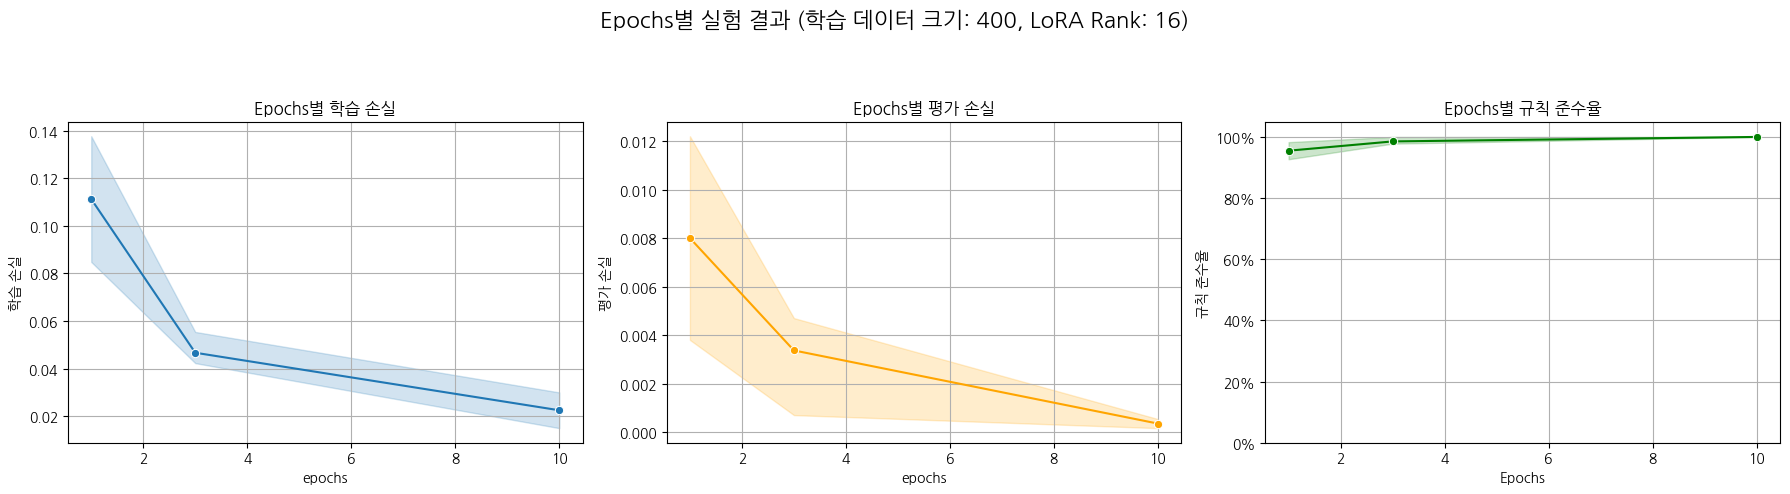

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if df is used
import matplotlib.font_manager as fm


# 폰트 경로 설정 및 matplotlib에 반영
nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
# matplotlib 폰트 관리자에 폰트를 명시적으로 추가
fm.fontManager.addfont(nanum_path)
plt.rcParams['font.family'] = 'NanumGothic' # 명시적으로 폰트 이름 설정
plt.rcParams['axes.unicode_minus'] = False # To prevent breaking minus sign

# Convert compliance_rate to numeric for plotting
df['compliance_rate_numeric'] = df['compliance_rate'].str.rstrip('%').astype(float) / 100

# 1행 3열로 변경하고 figsize 조정
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True) # Changed from (3,1) to (1,3) and adjusted figsize
fig.suptitle('Epochs별 실험 결과 (학습 데이터 크기: 400, LoRA Rank: 16)', fontsize=16) # Updated title to Korean

# Plot Train Loss
sns.lineplot(ax=axes[0], x='epochs', y='train_loss', data=df, marker='o')
axes[0].set_title('Epochs별 학습 손실') # Updated title to Korean
axes[0].set_ylabel('학습 손실') # Updated label to Korean
axes[0].grid(True)

# Plot Eval Loss
sns.lineplot(ax=axes[1], x='epochs', y='eval_loss', data=df, marker='o', color='orange')
axes[1].set_title('Epochs별 평가 손실') # Updated title to Korean
axes[1].set_ylabel('평가 손실') # Updated label to Korean
axes[1].grid(True)

# Plot Compliance Rate
sns.lineplot(ax=axes[2], x='epochs', y='compliance_rate_numeric', data=df, marker='o', color='green')
axes[2].set_title('Epochs별 규칙 준수율') # Updated title to Korean
axes[2].set_ylabel('규칙 준수율') # Updated label to Korean
axes[2].set_xlabel('Epochs')
axes[2].set_ylim(0, 1.05) # Set y-limit for percentage
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y))) # Format as percentage
axes[2].grid(True)

# Adjust rect for horizontal layout and suptitle
plt.tight_layout(rect=[0, 0, 1, 0.9]) # Adjusted rect for horizontal layout and suptitle
plt.show()

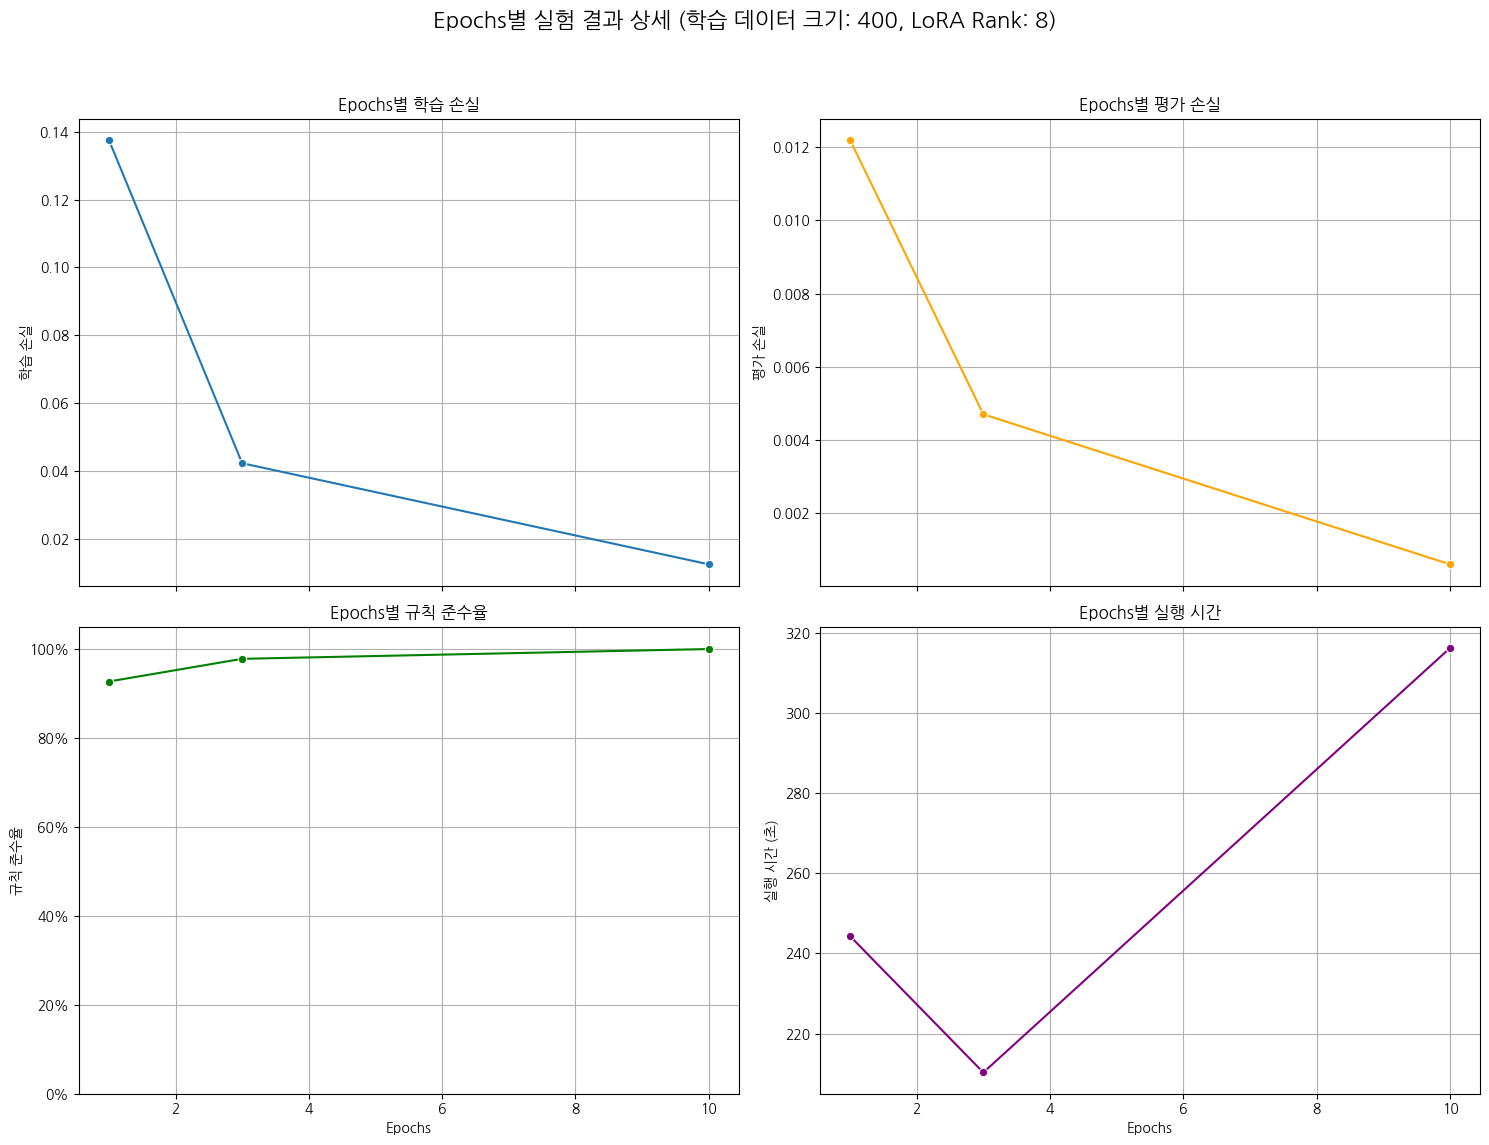

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.font_manager as fm

# 폰트 경로 설정 및 matplotlib에 반영
nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(nanum_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# df[9:12]의 데이터만 필터링하여 사용
df_filtered = df[9:12].copy()

# epochs 순서대로 정렬 (라인 플롯을 위해 중요)
df_filtered = df_filtered.sort_values(by='epochs').reset_index(drop=True)

# compliance_rate를 numeric으로 변환 (필요한 경우)
if 'compliance_rate_numeric' not in df_filtered.columns:
    df_filtered['compliance_rate_numeric'] = df_filtered['compliance_rate'].str.rstrip('%').astype(float) / 100

fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True) # 2x2 레이아웃
fig.suptitle('Epochs별 실험 결과 상세 (학습 데이터 크기: 400, LoRA Rank: 8)', fontsize=16)

# Plot Train Loss
sns.lineplot(ax=axes[0, 0], x='epochs', y='train_loss', data=df_filtered, marker='o')
axes[0, 0].set_title('Epochs별 학습 손실')
axes[0, 0].set_ylabel('학습 손실')
axes[0, 0].grid(True)

# Plot Eval Loss
sns.lineplot(ax=axes[0, 1], x='epochs', y='eval_loss', data=df_filtered, marker='o', color='orange')
axes[0, 1].set_title('Epochs별 평가 손실')
axes[0, 1].set_ylabel('평가 손실')
axes[0, 1].grid(True)

# Plot Compliance Rate
sns.lineplot(ax=axes[1, 0], x='epochs', y='compliance_rate_numeric', data=df_filtered, marker='o', color='green')
axes[1, 0].set_title('Epochs별 규칙 준수율')
axes[1, 0].set_ylabel('규칙 준수율')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
axes[1, 0].grid(True)

# Plot Execution Time
sns.lineplot(ax=axes[1, 1], x='epochs', y='execution_time_sec', data=df_filtered, marker='o', color='purple')
axes[1, 1].set_title('Epochs별 실행 시간')
axes[1, 1].set_ylabel('실행 시간 (초)')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
plt.show()